## Mục tiêu:
Thiết lập **Mô hình Cơ sở (Baseline Model)** sử dụng thuật toán ARIMA (Autoregressive Integrated Moving Average) nhằm dự báo giá đóng cửa của các tài sản tài chính.

**Các bước triển khai chính:**
* **Tiền xử lý & Chia tập dữ liệu:** Chia tập Train (80%) và Test (20%) theo đúng trình tự thời gian cho từng tài sản để ngăn chặn tuyệt đối hiện tượng rò rỉ dữ liệu.
* **Huấn luyện Auto-ARIMA trên tập Test:** Cho phép thuật toán tự động dò tìm cấu trúc $(p, d, q)$ tối ưu trực tiếp trên chuỗi giá trị tuyệt đối (`close`). Khả năng tự sai phân ($d$) của ARIMA sẽ xử lý tính không dừng (non-stationary) của chuỗi giá gốc.
* **Dự báo Tương lai & Định lượng Rủi ro:** Tái huấn luyện mô hình trên dữ liệu mới nhất để dự báo 24 giờ tiếp theo, đi kèm với việc trích xuất Khoảng tin cậy 95% (Confidence Interval) nhằm lượng hóa rủi ro của mô hình.

## Import các thư viện cần thiết

In [1]:
import pandas as pd
import numpy as np
import time
from datetime import timedelta
import pmdarima as pm
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import matplotlib.pyplot as plt
from IPython.display import display
from pathlib import Path

In [2]:
file_path = max(
    Path("../data/snapshots").glob("market_snapshot_*.csv")
)
print("Latest snapshot:", file_path)
df = pd.read_csv(file_path)

if 'time_timestamp' in df.columns:
    df['datetime'] = pd.to_datetime(df['time_timestamp'], unit='s')
else:
    df['datetime'] = pd.to_datetime(df['datetime'])
df = df.sort_values(['symbol', 'datetime']).reset_index(drop=True)

print(f"Đã tải Snapshot: {df.shape[0]} dòng, {df['symbol'].nunique()} tài sản.")

Latest snapshot: ..\data\snapshots\market_snapshot_20260510_150719.csv
Đã tải Snapshot: 71158 dòng, 27 tài sản.


## **1. Tiền xử lý & Chia tập dữ liệu**

In [3]:
df = df.sort_values(by=['symbol', 'datetime']).reset_index(drop=True)

df['row_num'] = df.groupby('symbol').cumcount()
df['total_rows'] = df.groupby('symbol')['symbol'].transform('count')

train_df = df[df['row_num'] < df['total_rows'] * 0.8].copy()
test_df = df[df['row_num'] >= df['total_rows'] * 0.8].copy()

train_df.drop(columns=['row_num', 'total_rows'], inplace=True)
test_df.drop(columns=['row_num', 'total_rows'], inplace=True)
df.drop(columns=['row_num', 'total_rows'], inplace=True)

print("--- THỐNG KÊ TẬP DỮ LIỆU ---")
print(f"Train size: {len(train_df)}")
print(f"Test size:  {len(test_df)}")
print(f"Số lượng tài sản trong tập Test: {test_df['symbol'].nunique()}")

--- THỐNG KÊ TẬP DỮ LIỆU ---
Train size: 56939
Test size:  14219
Số lượng tài sản trong tập Test: 27


## **2. Đánh giá Baseline trên tập Test**

Giai đoạn này đánh giá khả năng dự báo ngoài mẫu (out-of-sample) của mô hình ARIMA trên tập Test (20% dữ liệu cuối), nhằm xây dựng hệ quy chiếu sai số giữa các nhóm tài sản khác nhau.

### **Quy trình đánh giá:**

#### a. Huấn luyện toàn phần 
Mô hình được fit trên toàn bộ dữ liệu Train để khai thác tối đa cấu trúc và động lượng lịch sử của chuỗi thời gian.

#### b. Tự động hóa sai phân
Thông qua Auto-ARIMA với cơ chế tự chọn bậc sai phân, mô hình tự động:
- Kiểm định tính dừng (unit root)
- Xác định bậc sai phân tối ưu

Giúp chuyển chuỗi giá từ không dừng sang dừng mà không cần can thiệp thủ công.

#### c. Diễn giải hành vi thị trường
Việc trích xuất tham số ARIMA (p, d, q) cho phép suy luận đặc tính chuỗi giá:

- (0,1,0) → mô hình random walk  
- p, q > 0 → có yếu tố động lượng hoặc hồi quy  

Qua đó có thể hiểu cấu trúc thống kê của từng tài sản.

#### d. Chuẩn hóa đo lường sai số
Hiệu suất mô hình được đánh giá qua:

- RMSE (Root Mean Squared Error)
- MAE (Mean Absolute Error)
- MAPE (Mean Absolute Percentage Error)

Trong đó MAPE giúp:
- Chuẩn hóa sai số theo tỷ lệ %
- So sánh công bằng giữa các tài sản có mức giá khác nhau (Forex vs Crypto vs Stock)

In [4]:
arima_results = []

print("Đang khởi động Auto-ARIMA dự báo Giá (Close) trên tập Test...")
start_time = time.time()

for sym in test_df['symbol'].unique():
    y_train_arima = train_df[train_df['symbol'] == sym]['close'].values
    y_test_arima = test_df[test_df['symbol'] == sym]['close'].values
    
    try:
        model = pm.auto_arima(
            y_train_arima,
            seasonal=False,
            stepwise=True,
            suppress_warnings=True,
            max_p=3,
            max_q=3,
            d=None 
        )

        preds = model.predict(n_periods=len(y_test_arima))

        rmse = np.sqrt(mean_squared_error(y_test_arima, preds))
        mae = mean_absolute_error(y_test_arima, preds)
        
        mape = mean_absolute_percentage_error(y_test_arima, preds) * 100
        
        arima_results.append({
            'symbol': sym,
            'ARIMA_Order': str(model.order), 
            'ARIMA_RMSE': rmse,
            'ARIMA_MAE': mae,
            'ARIMA_MAPE (%)': mape 
        })
        
        print(f"[+] {sym:<10} | Lưới: {str(model.order):<10} | RMSE: {rmse:>12.4f} | MAPE: {mape:>8.2f}%")
        
    except Exception as e:
        print(f" Lỗi ARIMA tại {sym}: {e}")

df_baseline = pd.DataFrame(arima_results)

print(f"\nHoàn thành trong: {time.time() - start_time:.2f} giây")
display(df_baseline.sort_values('ARIMA_MAPE (%)').head(10))

Đang khởi động Auto-ARIMA dự báo Giá (Close) trên tập Test...
[+] AAPL       | Lưới: (0, 1, 0)  | RMSE:      15.2458 | MAPE:     4.34%
[+] ADA-USD    | Lưới: (2, 1, 0)  | RMSE:       0.0591 | MAPE:    19.95%
[+] AMZN       | Lưới: (0, 1, 0)  | RMSE:      44.6489 | MAPE:    15.93%
[+] AUDUSD=X   | Lưới: (0, 1, 3)  | RMSE:       0.0236 | MAPE:     3.04%
[+] AVAX-USD   | Lưới: (1, 1, 2)  | RMSE:       1.7589 | MAPE:    16.76%
[+] BNB-USD    | Lưới: (1, 1, 0)  | RMSE:      94.3285 | MAPE:    13.38%
[+] BTC-USD    | Lưới: (1, 1, 0)  | RMSE:   15106.8485 | MAPE:    17.62%
[+] DOGE-USD   | Lưới: (2, 1, 0)  | RMSE:       0.0237 | MAPE:    18.78%
[+] ETH-USD    | Lưới: (1, 1, 0)  | RMSE:     248.0277 | MAPE:    10.08%


d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


[+] EURUSD=X   | Lưới: (0, 1, 0)  | RMSE:       0.0190 | MAPE:     1.51%


d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


[+] GBPUSD=X   | Lưới: (0, 1, 0)  | RMSE:       0.0283 | MAPE:     1.96%
[+] GC=F       | Lưới: (3, 1, 2)  | RMSE:      90.5767 | MAPE:     1.60%
[+] GOOGL      | Lưới: (3, 1, 3)  | RMSE:      56.7613 | MAPE:    13.46%
[+] LINK-USD   | Lưới: (1, 1, 0)  | RMSE:       0.7535 | MAPE:     6.73%
[+] META       | Lưới: (0, 1, 0)  | RMSE:      71.4388 | MAPE:     9.77%
[+] MSFT       | Lưới: (0, 1, 0)  | RMSE:      58.3608 | MAPE:    12.41%
[+] NVDA       | Lưới: (0, 1, 1)  | RMSE:      24.3446 | MAPE:    10.90%
[+] SI=F       | Lưới: (3, 1, 2)  | RMSE:       4.3650 | MAPE:     4.57%
[+] SOL-USD    | Lưới: (2, 1, 2)  | RMSE:      17.8443 | MAPE:    18.30%
[+] TSLA       | Lưới: (0, 1, 0)  | RMSE:      37.5573 | MAPE:     8.18%
[+] USDCAD=X   | Lưới: (0, 1, 2)  | RMSE:       0.0221 | MAPE:     1.44%
[+] USDCHF=X   | Lưới: (0, 1, 0)  | RMSE:       0.0146 | MAPE:     1.70%
[+] USDJPY=X   | Lưới: (2, 1, 3)  | RMSE:       1.4807 | MAPE:     0.64%
[+] XRP-USD    | Lưới: (2, 1, 0)  | RMSE:       0.2

,symbol,ARIMA_Order,ARIMA_RMSE,ARIMA_MAE,ARIMA_MAPE (%)
22,USDJPY=X,"(2, 1, 3)",1.480732,1.007981,0.640107
20,USDCAD=X,"(0, 1, 2)",0.022050,0.019631,1.436347
9,EURUSD=X,"(0, 1, 0)",0.018987,0.017763,1.512928
11,GC=F,"(3, 1, 2)",90.576680,75.711359,1.603431
21,USDCHF=X,"(0, 1, 0)",0.014570,0.013341,1.703740
10,GBPUSD=X,"(0, 1, 0)",0.028347,0.026485,1.957451
3,AUDUSD=X,"(0, 1, 3)",0.023580,0.021780,3.039631
0,AAPL,"(0, 1, 0)",15.245764,12.042901,4.338199
17,SI=F,"(3, 1, 2)",4.364961,3.570210,4.567891
24,^DJI,"(0, 1, 1)",2396.406645,2262.711781,4.602493


### **Nhận xét và phân tích kết quả đánh giá baseline (ARIMA)**

Dựa trên bảng xếp hạng hiệu suất dự báo của 10 tài sản tốt nhất, có thể rút ra một số kết luận quan trọng về đặc tính thị trường và hành vi của mô hình ARIMA.

#### 1. Vai trò của MAPE trong chuẩn hóa đánh giá

Kết quả cho thấy MAPE (Mean Absolute Percentage Error) đóng vai trò quan trọng trong việc chuẩn hóa sai số giữa các tài sản có thang đo khác nhau.

Ví dụ:
- Vàng (GC=F): RMSE rất lớn (~90.57) nhưng MAPE khoảng 1.60%
- EUR/USD: RMSE rất nhỏ (~0.018) nhưng MAPE khoảng 1.51%

Điều này cho thấy:
- RMSE và MAE bị ảnh hưởng mạnh bởi thang giá
- MAPE giúp quy đổi sai số về dạng phần trăm
- Cho phép so sánh công bằng giữa Forex, Stock và Commodities

#### 2. Sự thống trị của Forex và kim loại quý

Nhóm tài sản có sai số thấp nhất (MAPE < 2%) chủ yếu thuộc về:
- Các cặp tiền tệ lớn như USD/JPY, USD/CAD, EUR/USD
- Vàng (Gold Futures)

Kết luận:
- Thị trường Forex và vàng có tính thanh khoản cao
- Biến động tương đối ổn định
- Ít chịu ảnh hưởng từ nhiễu ngắn hạn
- Phù hợp tốt với mô hình tuyến tính như ARIMA

#### 3. Giải mã cấu trúc thị trường qua (p, d, q)

Việc phân tích tham số ARIMA_Order cho phép suy luận đặc tính chuỗi giá.

##### a. Thị trường random walk
Ví dụ: EUR/USD, GBP/USD, AAPL  
Cấu trúc: (0, 1, 0)

Ý nghĩa:
- Thị trường có mức hiệu quả cao
- Biến động gần như ngẫu nhiên
- Thông tin phản ánh ngay vào giá
- Dự báo tối ưu nhất là giữ nguyên giá trị hiện tại

##### b. Thị trường có cấu trúc dự báo được
Ví dụ: USD/JPY (2, 1, 3), Gold (3, 1, 2)

Ý nghĩa:
- Có yếu tố tự hồi quy và trung bình trượt
- Tồn tại độ trễ thông tin hoặc chu kỳ ngắn hạn
- ARIMA có thể khai thác được cấu trúc thống kê này để giảm sai số

---

#### Kết luận

- MAPE là thước đo quan trọng giúp chuẩn hóa và so sánh công bằng giữa các tài sản
- Forex và vàng là nhóm phù hợp nhất với ARIMA
- Cấu trúc (p, d, q) phản ánh mức độ hiệu quả của thị trường:
  - (0,1,0) tương ứng với thị trường hiệu quả cao và gần random walk
  - (p > 0, q > 0) cho thấy tồn tại cấu trúc có thể dự báo

ARIMA phù hợp nhất với các thị trường có cấu trúc ổn định và mức nhiễu vừa phải, nơi vẫn tồn tại một phần quy luật thống kê có thể khai thác

## **3. Dự báo Tương lai** 

Sử dụng kiến trúc Local ARIMA để dự báo trực tiếp Giá đóng cửa cho 24 giờ tiếp theo chưa từng xảy ra của các tài sản. 

Ở bước này, mô hình sẽ được tái huấn luyện trên 1000 nến dữ liệu gần nhất để nắm bắt động lượng hiện tại của thị trường. Hệ thống đồng thời trích xuất **Khoảng tin cậy 95% (Confidence Interval)** nhằm lượng hóa rủi ro cho các dự báo tương lai.

In [5]:
forecast_horizon = 24 
all_forecasts = []

print(f"ĐANG KHỞI ĐỘNG DỰ BÁO TƯƠNG LAI CHO {df['symbol'].nunique()} TÀI SẢN...")
start_time = time.time()

for sym in df['symbol'].unique():
    # Giới hạn 1000 nến gần nhất để tăng tốc độ và tránh nhiễu quá khứ xa
    data_sym = df[df['symbol'] == sym].tail(1000)
    y_train = data_sym['close'].values
    
    try:
        model = pm.auto_arima(
            y_train, 
            seasonal=False, 
            stepwise=True, 
            suppress_warnings=True, 
            max_p=3, max_q=3,
            d=None
        )
        
        # Trích xuất Dự báo và Khoảng tin cậy 95%
        preds, conf_int = model.predict(n_periods=forecast_horizon, return_conf_int=True, alpha=0.05)
        
        last_dt = pd.to_datetime(data_sym['datetime'].iloc[-1])
        future_dates = [last_dt + timedelta(hours=i) for i in range(1, forecast_horizon + 1)]
        
        for i in range(forecast_horizon):
            all_forecasts.append({
                'symbol': sym,
                'datetime': future_dates[i],
                'predicted_close': round(float(preds[i]), 4),
                'lower_bound': round(float(conf_int[i][0]), 4),
                'upper_bound': round(float(conf_int[i][1]), 4)
            })
            
        print(f"[+] {sym:<10} | Hoàn tất dự báo 24h tới.")
        
    except Exception as e:
        print(f" Lỗi dự báo tại {sym}: {e}")

df_forecast = pd.DataFrame(all_forecasts)
print(f"\nHoàn thành trong: {time.time() - start_time:.2f} giây")

ĐANG KHỞI ĐỘNG DỰ BÁO TƯƠNG LAI CHO 27 TÀI SẢN...
[+] AAPL       | Hoàn tất dự báo 24h tới.
[+] ADA-USD    | Hoàn tất dự báo 24h tới.
[+] AMZN       | Hoàn tất dự báo 24h tới.
[+] AUDUSD=X   | Hoàn tất dự báo 24h tới.
[+] AVAX-USD   | Hoàn tất dự báo 24h tới.
[+] BNB-USD    | Hoàn tất dự báo 24h tới.
[+] BTC-USD    | Hoàn tất dự báo 24h tới.


d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


[+] DOGE-USD   | Hoàn tất dự báo 24h tới.
[+] ETH-USD    | Hoàn tất dự báo 24h tới.
[+] EURUSD=X   | Hoàn tất dự báo 24h tới.


d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1901: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ar)**-1
d:\Miniconda\envs\environment\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:1908: RuntimeWarning: divide by zero encountered in reciprocal
  return np.roots(self.polynomial_reduced_ma)**-1


[+] GBPUSD=X   | Hoàn tất dự báo 24h tới.
[+] GC=F       | Hoàn tất dự báo 24h tới.
[+] GOOGL      | Hoàn tất dự báo 24h tới.
[+] LINK-USD   | Hoàn tất dự báo 24h tới.
[+] META       | Hoàn tất dự báo 24h tới.
[+] MSFT       | Hoàn tất dự báo 24h tới.
[+] NVDA       | Hoàn tất dự báo 24h tới.
[+] SI=F       | Hoàn tất dự báo 24h tới.
[+] SOL-USD    | Hoàn tất dự báo 24h tới.
[+] TSLA       | Hoàn tất dự báo 24h tới.
[+] USDCAD=X   | Hoàn tất dự báo 24h tới.
[+] USDCHF=X   | Hoàn tất dự báo 24h tới.
[+] USDJPY=X   | Hoàn tất dự báo 24h tới.
[+] XRP-USD    | Hoàn tất dự báo 24h tới.
[+] ^DJI       | Hoàn tất dự báo 24h tới.
[+] ^GSPC      | Hoàn tất dự báo 24h tới.
[+] ^IXIC      | Hoàn tất dự báo 24h tới.

Hoàn thành trong: 78.82 giây


## **4. Trực quan hóa Kết quả Dự báo & Định lượng Rủi ro**

Vẽ biểu đồ kết nối giữa **Dữ liệu Lịch sử (100 giờ gần nhất)** và **Dữ liệu Dự báo (24 giờ tiếp theo)** cho một vài tài sản đại diện. 

Biểu đồ bao gồm vùng đổ bóng đại diện cho Khoảng tin cậy 95%. Độ mở rộng của vùng đổ bóng thể hiện mức độ gia tăng rủi ro và tính bất định (Uncertainty) khi thời gian dự báo càng tiến xa về tương lai.

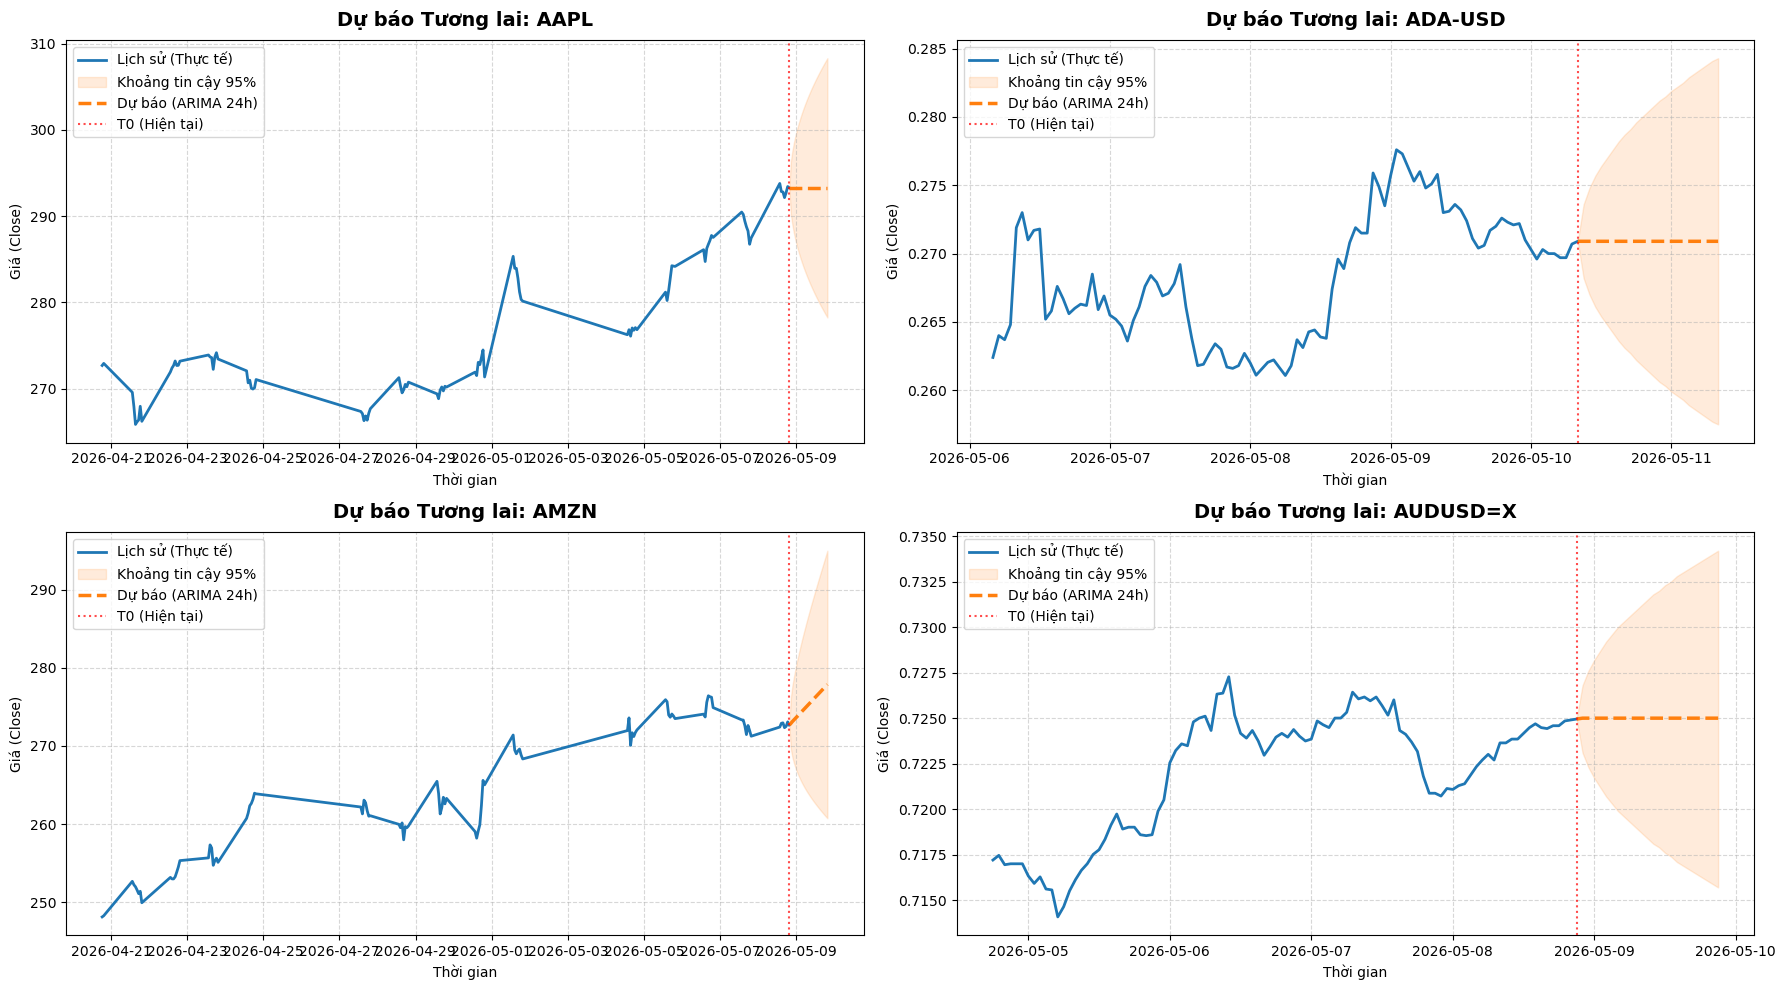

In [6]:
# Lấy 4 symbol đầu tiên làm đại diện
sample_symbols = df['symbol'].unique()[:4] 
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes = axes.flatten()

for i, sym in enumerate(sample_symbols):
    hist_data = df[df['symbol'] == sym].tail(100)
    pred_data = df_forecast[df_forecast['symbol'] == sym]
    
    # Vẽ Dữ liệu thực tế
    axes[i].plot(hist_data['datetime'], hist_data['close'], 
                 label='Lịch sử (Thực tế)', color='#1f77b4', linewidth=2)
    
    combined_dates = [hist_data['datetime'].iloc[-1]] + list(pred_data['datetime'])
    combined_prices = [hist_data['close'].iloc[-1]] + list(pred_data['predicted_close'])
    combined_lower = [hist_data['close'].iloc[-1]] + list(pred_data['lower_bound'])
    combined_upper = [hist_data['close'].iloc[-1]] + list(pred_data['upper_bound'])
    
    # Vẽ Khoảng tin cậy 95%
    axes[i].fill_between(combined_dates, combined_lower, combined_upper, 
                         color='#ff7f0e', alpha=0.15, label='Khoảng tin cậy 95%')
    
    axes[i].plot(combined_dates, combined_prices, 
                 label='Dự báo (ARIMA 24h)', color='#ff7f0e', linestyle='--', linewidth=2.5)
    
    axes[i].axvline(x=hist_data['datetime'].iloc[-1], color='red', linestyle=':', 
                    alpha=0.7, label='T0 (Hiện tại)')
    
    axes[i].set_title(f'Dự báo Tương lai: {sym}', fontsize=14, fontweight='bold', pad=10)
    axes[i].set_xlabel('Thời gian', fontsize=10)
    axes[i].set_ylabel('Giá (Close)', fontsize=10)
    axes[i].legend(loc='best')
    axes[i].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

### **Nhận xét biểu đồ dự báo**

#### 1. Hiện tượng dự báo đi ngang 

Quan sát trên AAPL, ADA-USD và AUDUSD=X, đường dự báo trung tâm sau thời điểm T0 gần như nằm ngang.

Phân tích:
- Đây là đặc trưng của mô hình khi dữ liệu mang tính random walk
- Biến động ngắn hạn chủ yếu là nhiễu
- Mô hình không tìm thấy tín hiệu xu hướng đủ mạnh
- Dự báo tối ưu trở thành giữ nguyên giá hiện tại


#### 2. Khả năng ngoại suy xu hướng

Trường hợp AMZN có sự khác biệt rõ rệt với đường dự báo đi lên.

Phân tích:
- Dữ liệu trước T0 có động lượng tăng rõ ràng
- Mô hình nhận diện được xu hướng (momentum)
- ARIMA tiếp tục ngoại suy xu hướng này sang tương lai gần

#### 3. Lượng hóa rủi ro

Cả 4 biểu đồ đều thể hiện vùng tin cậy 95% mở rộng dần theo thời gian.

Phân tích:
- Vùng dự báo hẹp tại T0 và mở rộng về phía tương lai
- Thời gian càng xa, độ bất định càng lớn
- Sai số dự báo tăng theo horizon

---

## Kết luận

Bốn biểu đồ thể hiện rõ đặc trưng của mô hình ARIMA:

- Khi không có tín hiệu rõ ràng, mô hình ưu tiên dự báo đi ngang (random walk)
- Khi có xu hướng mạnh, mô hình có thể ngoại suy (trend / drift)
- Khoảng tin cậy phản ánh đúng bản chất bất định tăng theo thời gian

Tổng thể, ARIMA thể hiện hành vi thận trọng và nhất quán với dữ liệu tài chính thực tế, đặc biệt trong việc cân bằng giữa xu hướng và rủi ro dự báo